In [1]:
# Stage 8, Baseline Machine Learning

import pandas as pd
import numpy as np
import psycopg2

In [3]:
# Connect to PostgreSQL

connection = psycopg2.connect(
    host="host.docker.internal",
    port=5433,
    database="food_hygiene",
    user="postgres",
    password="postgres"
)

query = """
SELECT *
FROM gold.fct_food_hygiene_ml;
"""

df = pd.read_sql(query, connection)

print(df.shape)
df.head()

(300, 11)


/tmp/ipykernel_102/3885867120.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,fhrsid,business_type,local_authority_name,postcode_area,rating_year,rating_month,scheme_type,latitude,longitude,coordinates_missing,is_low_hygiene_rating
0,1315149,Retailers - other,Waltham Forest,E,2025.0,11.0,FHRS,51.561495,0.000577,0,1
1,1675432,Restaurant/Cafe/Canteen,Birmingham,B,2025.0,2.0,FHRS,NaN,NaN,1,1
2,1073476,Restaurant/Cafe/Canteen,Ealing,UB,2026.0,3.0,FHRS,51.500790,-0.383498,0,1
3,1793292,Retailers - other,Birmingham,B,2026.0,3.0,FHRS,NaN,NaN,1,1
4,1933822,Takeaway/sandwich shop,Waltham Forest,E,2026.0,6.0,FHRS,51.568799,-0.028770,0,1


In [4]:
# Define features X and target y

feature_columns = [
    "business_type",
    "postcode_area",
    "rating_year",
    "rating_month",
    "latitude",
    "longitude",
    "coordinates_missing"
]

X = df[feature_columns]

y = df["is_low_hygiene_rating"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (300, 7)
y shape: (300,)

Target distribution:
is_low_hygiene_rating
1    150
0    150
Name: count, dtype: int64


In [5]:
from sklearn.model_selection import train_test_split

# Split data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTest target:")
print(y_test.value_counts())

X_train: (240, 7)
X_test: (60, 7)

Training target:
is_low_hygiene_rating
1    120
0    120
Name: count, dtype: int64

Test target:
is_low_hygiene_rating
0    30
1    30
Name: count, dtype: int64


## 8.6 Dummy Classifier

The Dummy Classifier provides a minimum baseline for the project.

It does not learn meaningful patterns from the features. Instead, it predicts using a simple rule, in this case the most frequent class.

This gives us a benchmark that every real machine learning model should beat.

Because the development dataset is balanced:

- Class 0 = 150 businesses
- Class 1 = 150 businesses

the expected accuracy is approximately 50%.

The purpose is therefore to answer:

**Can a real predictive model perform better than a naive baseline?**

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


# Define feature groups

categorical_features = [
    "business_type",
    "postcode_area"
]

numeric_features = [
    "rating_year",
    "rating_month",
    "latitude",
    "longitude"
]

binary_features = [
    "coordinates_missing"
]


# Numeric preprocessing
numeric_pipeline = Pipeline([
    # Fill missing latitude/longitude using the training-set median
    ("imputer", SimpleImputer(strategy="median")),

    # Put numeric variables onto similar scales
    ("scaler", StandardScaler())
])


# Categorical preprocessing
categorical_pipeline = Pipeline([
    # Safeguard against missing categories
    ("imputer", SimpleImputer(strategy="most_frequent")),

    # Convert categories into 0/1 columns
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


# Combine preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
    ("binary", "passthrough", binary_features)
])

print("Preprocessing pipeline created")

Preprocessing pipeline created


In [7]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report

# Build a pipeline:
# preprocessing first, then dummy classifier
dummy_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

# Train
dummy_model.fit(X_train, y_train)

# Predict
dummy_predictions = dummy_model.predict(X_test)

# Evaluate
dummy_accuracy = accuracy_score(y_test, dummy_predictions)

print("Dummy Accuracy:", dummy_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, dummy_predictions, zero_division=0))

Dummy Accuracy: 0.5

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67        30
           1       0.00      0.00      0.00        30

    accuracy                           0.50        60
   macro avg       0.25      0.50      0.33        60
weighted avg       0.25      0.50      0.33        60



## 8.7 Logistic Regression

Logistic Regression is used as the first real baseline model because the target is binary:

- 0 = not low hygiene risk
- 1 = low hygiene risk

It is a simple and interpretable classification model that estimates the probability of a business belonging to the low-hygiene-risk class.

It provides a useful comparison point before testing more complex non-linear models.

The main question is:

**Can a relatively simple linear model identify useful patterns in the engineered public-data features and outperform the Dummy Classifier?**

In [9]:
from sklearn.linear_model import LogisticRegression

# Build Logistic Regression pipeline
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
logistic_predictions = logistic_model.predict(X_test)

# Evaluate
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:", logistic_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

Logistic Regression Accuracy: 0.6833333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.63      0.67        30
           1       0.67      0.73      0.70        30

    accuracy                           0.68        60
   macro avg       0.69      0.68      0.68        60
weighted avg       0.69      0.68      0.68        60



## 8.8 Decision Tree

The Decision Tree is used as the first non-linear baseline model.

Unlike Logistic Regression, it does not assume a linear relationship between the input features and the target.

Instead, it learns a sequence of decision rules, for example:

- Is the business type a takeaway?
- Is the postcode area a certain category?
- Is the rating year above a certain value?

This allows the model to capture interactions and threshold effects that Logistic Regression may miss.

The purpose is to answer:

**Do non-linear decision rules improve prediction of low hygiene risk compared with Logistic Regression and the Dummy baseline?**

In [10]:
from sklearn.tree import DecisionTreeClassifier

# Build Decision Tree pipeline
decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

# Train
decision_tree_model.fit(X_train, y_train)

# Predict
decision_tree_predictions = decision_tree_model.predict(X_test)

# Evaluate
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Accuracy:", decision_tree_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        decision_tree_predictions,
        zero_division=0
    )
)

Decision Tree Accuracy: 0.7

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.80      0.73        30
           1       0.75      0.60      0.67        30

    accuracy                           0.70        60
   macro avg       0.71      0.70      0.70        60
weighted avg       0.71      0.70      0.70        60



## 8.9 Random Forest

Random Forest is used as an ensemble baseline model.

It combines many Decision Trees instead of relying on a single tree.

Each tree is trained on a slightly different sample of the training data and a different subset of features. Their predictions are then combined.

This usually makes the model more stable and less sensitive to overfitting than a single Decision Tree.

Random Forest is well suited to structured tabular data and can capture complex non-linear relationships and interactions between features.

The purpose is to answer:

**Does combining many decision trees improve predictive performance and stability compared with a single Decision Tree?**

In [11]:
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest pipeline
random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train
random_forest_model.fit(X_train, y_train)

# Predict
random_forest_predictions = random_forest_model.predict(X_test)

# Evaluate
random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print("Random Forest Accuracy:", random_forest_accuracy)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        zero_division=0
    )
)

Random Forest Accuracy: 0.6833333333333333

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69        30
           1       0.69      0.67      0.68        30

    accuracy                           0.68        60
   macro avg       0.68      0.68      0.68        60
weighted avg       0.68      0.68      0.68        60



## 8.10 Baseline Model Comparison

The baseline models are compared to determine whether increasingly complex models improve prediction.

The models are:

- Dummy Classifier
- Logistic Regression
- Decision Tree
- Random Forest

Accuracy is useful because the development target is deliberately balanced at 50% class 0 and 50% class 1.

F1 score is also included because it considers both precision and recall.

At this stage, the goal is not to select the final tuned model.

The goal is to establish a baseline benchmark that can be improved during Stage 9.

In [12]:
from sklearn.metrics import f1_score

# Create baseline comparison table

baseline_results = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        dummy_accuracy,
        logistic_accuracy,
        decision_tree_accuracy,
        random_forest_accuracy
    ],

    "F1 Score": [
        f1_score(y_test, dummy_predictions),
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, decision_tree_predictions),
        f1_score(y_test, random_forest_predictions)
    ]
})

# Sort best accuracy first
baseline_results = baseline_results.sort_values(
    by="Accuracy",
    ascending=False
)

baseline_results

,Model,Accuracy,F1 Score
2,Decision Tree,0.700000,0.666667
1,Logistic Regression,0.683333,0.698413
3,Random Forest,0.683333,0.677966
0,Dummy Classifier,0.500000,0.000000


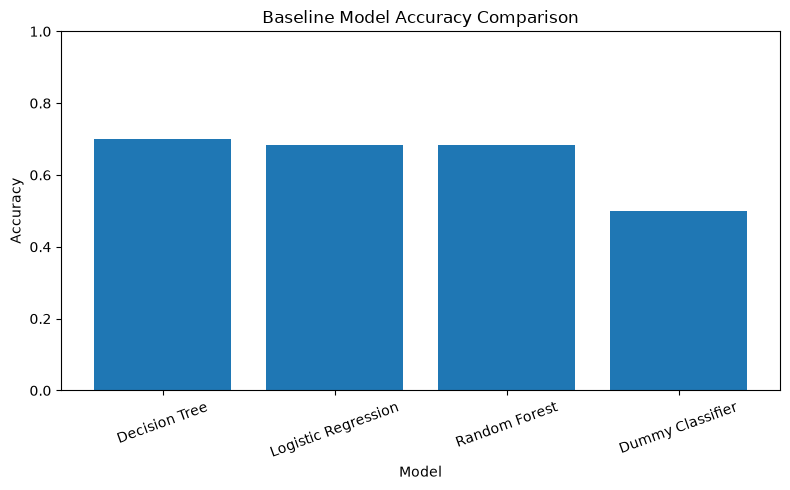

In [13]:
import matplotlib.pyplot as plt

# Plot baseline model accuracy

plt.figure(figsize=(8, 5))

plt.bar(
    baseline_results["Model"],
    baseline_results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Baseline Model Accuracy Comparison")

plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 8.12 Save Baseline Results

The baseline model performance is saved so that later tuned models can be compared against the same benchmark.

This preserves the Stage 8 results before any hyperparameter tuning or advanced model optimisation is performed.

In [14]:
from pathlib import Path

# Create results folder if it does not already exist
results_folder = Path("../results")
results_folder.mkdir(exist_ok=True)

# Save baseline model comparison
baseline_results.to_csv(
    results_folder / "baseline_model_results.csv",
    index=False
)

print("Baseline results saved.")

Baseline results saved.


## 8.13 Final Baseline Check

The final baseline results are reviewed before moving to model tuning.

The purpose is to identify:

- Whether the real models beat the Dummy Classifier
- Which baseline model achieved the highest accuracy
- Which model achieved the highest F1 score
- What performance Stage 9 needs to improve upon

In [15]:
# Final Stage 8 baseline check

print(baseline_results)

best_accuracy_model = baseline_results.loc[
    baseline_results["Accuracy"].idxmax()
]

best_f1_model = baseline_results.loc[
    baseline_results["F1 Score"].idxmax()
]

print("\nBest model by Accuracy:")
print(best_accuracy_model)

print("\nBest model by F1 Score:")
print(best_f1_model)

                 Model  Accuracy  F1 Score
2        Decision Tree  0.700000  0.666667
1  Logistic Regression  0.683333  0.698413
3        Random Forest  0.683333  0.677966
0     Dummy Classifier  0.500000  0.000000

Best model by Accuracy:
Model       Decision Tree
Accuracy              0.7
F1 Score         0.666667
Name: 2, dtype: object

Best model by F1 Score:
Model       Logistic Regression
Accuracy               0.683333
F1 Score               0.698413
Name: 1, dtype: object
